# Analysis of model results

## Imports

In [26]:
import arviz as az
import bambi as bmb
import polars as  pl
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

from kidney.paths import RESULTS_DIR, PREPARED_FILES, PLOT_DIR
from kidney.plotting import forestplot_oz, plot_ppc
from kidney.sign_probs import get_sign_probs, get_signif

In [27]:
## Makes Illustrator recognize text in saved PDF figures:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'

## Configuration

In [28]:
az.rcParams["data.load"] = "eager"

# Analysis

In [29]:
idata_frequency = az.from_netcdf(RESULTS_DIR / "idata_excretion_glucose_empa_minus_vehicle.nc")
idata_frequency_bsl = az.from_netcdf(RESULTS_DIR / "idata_excretion_glucose_vehicle.nc")
idata_frequency

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data

In [30]:
print("change in glucose excretion between empa and vehicle:")
display(az.summary(idata_frequency, var_names=["~mu", "~1|rat"]))
print("Glucose excretion at baseline (vehicle):")
display(az.summary(idata_frequency_bsl, var_names=["~mu", "~1|rat"]))

change in glucose excretion between empa and vehicle:


/Users/lampochka/Desktop/kidney_test/kidney/.venv/lib/python3.14/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['1|rat'] have not been found and will be ignored
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,2.233,0.314,1.670,2.812,0.006,0.006,2914.0,2445.0,1.0
Intercept,2.598,0.851,1.003,4.231,0.015,0.014,3304.0,2876.0,1.0
gtyp[fa/fa],-1.079,1.242,-3.453,1.257,0.024,0.020,2772.0,2717.0,1.0
age[Young],-0.939,1.182,-3.083,1.315,0.023,0.020,2731.0,2882.0,1.0
sex[M],0.251,1.166,-1.840,2.483,0.023,0.019,2446.0,2649.0,1.0
"gtyp:age[fa/fa, Young]",-0.661,1.627,-3.793,2.238,0.032,0.028,2594.0,2576.0,1.0
"gtyp:sex[fa/fa, M]",1.224,1.606,-1.677,4.282,0.033,0.025,2304.0,2619.0,1.0


Glucose excretion at baseline (vehicle):


/Users/lampochka/Desktop/kidney_test/kidney/.venv/lib/python3.14/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['1|rat'] have not been found and will be ignored
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-0.033,0.376,-0.745,0.693,0.007,0.006,3176.0,2685.0,1.0
gtyp[fa/fa],2.149,0.598,1.008,3.255,0.012,0.010,2555.0,2174.0,1.0
age[Young],0.098,0.534,-0.942,1.081,0.011,0.009,2193.0,2458.0,1.0
sex[M],0.182,0.514,-0.806,1.128,0.010,0.009,2644.0,2596.0,1.0
"gtyp:age[fa/fa, Young]",0.179,0.774,-1.233,1.692,0.016,0.013,2333.0,2373.0,1.0
"gtyp:sex[fa/fa, M]",-0.247,0.769,-1.709,1.207,0.015,0.012,2784.0,2662.0,1.0
sigma_Intercept,-0.035,0.202,-0.405,0.331,0.004,0.003,2972.0,2709.0,1.0
sigma_gtyp[fa/fa],0.157,0.272,-0.344,0.675,0.005,0.004,3163.0,2750.0,1.0
sigma[0],0.986,0.209,0.664,1.388,0.004,0.004,2972.0,2709.0,1.0
sigma[1],0.986,0.209,0.664,1.388,0.004,0.004,2972.0,2709.0,1.0


## Compute and plot TS for all groups

In [8]:
t_groups_change, t_groups_bsl = (
    {
        "fa/+:female:adult":   idata.posterior["Intercept"],
        "fa/+:female:young":   idata.posterior["Intercept"] + idata.posterior["age"],
        "fa/+:male:adult":     idata.posterior["Intercept"] + idata.posterior["sex"],
        "fa/+:male:young":     idata.posterior["Intercept"] + idata.posterior["sex"] + idata.posterior["age"],
        "fa/fa:female:adult":  idata.posterior["Intercept"] + idata.posterior["gtyp"],
        "fa/fa:female:young":  idata.posterior["Intercept"] + idata.posterior["gtyp"] + idata.posterior["age"] + idata.posterior["gtyp:age"],
        "fa/fa:male:adult":    idata.posterior["Intercept"] + idata.posterior["gtyp"] + idata.posterior["sex"] + idata.posterior["gtyp:sex"],
        "fa/fa:male:young":    idata.posterior["Intercept"] + idata.posterior["gtyp"] + idata.posterior["sex"] + idata.posterior["gtyp:sex"] + idata.posterior["age"] + idata.posterior["gtyp:age"],
    }
    for idata in (idata_frequency, idata_frequency_bsl)
)

In [9]:
ts_change, ts_vehicle = (
    {
    "fa/fa adult M":   t_groups["fa/fa:male:adult"],
    "fa/fa young M":   t_groups["fa/fa:male:young"],
    "fa/+ adult M":    t_groups["fa/+:male:adult"],
    "fa/+ young M":    t_groups["fa/+:male:young"],
    "fa/fa adult F":   t_groups["fa/fa:female:adult"],
    "fa/fa young F":   t_groups["fa/fa:female:young"],
    "fa/+ adult F":    t_groups["fa/+:female:adult"],
    "fa/+ young F":    t_groups["fa/+:female:young"],
    }
    for t_groups in (t_groups_change, t_groups_bsl)
)

sign_probabilities_change = pd.DataFrame({
    'change':get_sign_probs(ts_change),
    'change_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_change).items()},
})

print("Change sign probabilities:")
display(get_sign_probs(ts_change))
print("Baseline sign probabilities:")
display(get_sign_probs(ts_vehicle))

Change sign probabilities:


{'fa/fa adult M': 0.998,
 'fa/fa young M': 0.90375,
 'fa/+ adult M': 0.9975,
 'fa/+ young M': 0.9715,
 'fa/fa adult F': 0.95675,
 'fa/fa young F': 0.468,
 'fa/+ adult F': 0.998,
 'fa/+ young F': 0.9205}

Baseline sign probabilities:


{'fa/fa adult M': 1.0,
 'fa/fa young M': 1.0,
 'fa/+ adult M': 0.64825,
 'fa/+ young M': 0.721,
 'fa/fa adult F': 1.0,
 'fa/fa young F': 1.0,
 'fa/+ adult F': 0.46525,
 'fa/+ young F': 0.54925}

## <font color='red'>Teddy, in the following plot, left panel, all fa/+ are consistent with zero. If I plot np.exp(TS), they are higher than zero. Should TS or np.exp(TS) be used for making a conclusion about whether glucose excretion is zero at baseline (vehicle stage)? </font>

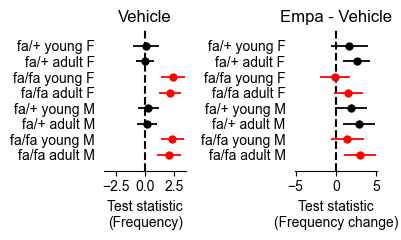

In [12]:
f, axes = plt.subplots(1, 2, figsize=(4, 2.5))
axes[1] = forestplot_oz(axes[1], ts_change);
axes[1].set_title("Empa - Vehicle");

axes[0] = forestplot_oz(axes[0], ts_vehicle);
axes[0].set_title("Vehicle");

for ax in axes:
    ax.spines[['top', 'right', 'left']].set_visible(False)
axes[1].set_xlabel('Test statistic\n(Glucose excretion change)')
axes[0].set_xlabel('Test statistic\n(Glucose excretion)')

# axes[0].set_xlim(-1.3, 3.9)
# axes[1].set_xlim(-2.4, 5.5)

f.tight_layout()
# f.savefig(PLOT_DIR / "ts_ExcretionGlucose_groups.pdf", bbox_inches="tight")

## Compute and plot TS representing the difference between fa/fa and fa/+ genotypes

In [13]:
ts_change, ts_vehicle = (
    {
        "M adult":   t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"],
        "M young":   t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"],
        # "M": (t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"] + t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"])/2,
        "F adult": t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"],
        "F young": t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"],    
        # "F": (t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"] + t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"])/2
        # "adult": (t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"] + t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"])/2,
        # "young": (t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"] + t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"])/2
       
    }
    for t_groups in (t_groups_change, t_groups_bsl)
)

sign_probabilities_gtyp = pd.DataFrame({
    'change':get_sign_probs(ts_change),
    'change_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_change).items()},
    'vehicle':get_sign_probs(ts_vehicle),
    'vehicle_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_vehicle).items()},
})

print("Empa sign probabilities:")
display(get_sign_probs(ts_change))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))

Empa sign probabilities:


{'M adult': 0.54875, 'M young': 0.35925, 'F adult': 0.18875, 'F young': 0.1245}


Vehicle sign probabilities:


{'M adult': 0.9965, 'M young': 0.9975, 'F adult': 0.99925, 'F young': 0.99875}

[]

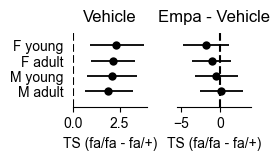

In [15]:
f, axes = plt.subplots(1, 2, figsize=(2.3, 1))
plt.subplots_adjust(wspace=0.4)

for ax, ts_, tle in zip(axes, (ts_vehicle, ts_change), ('Vehicle', 'Empa - Vehicle')):
    ax = forestplot_oz(ax, ts_);
    ax.set_title(tle);
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('TS (fa/fa - fa/+)')


axes[0].set_xlim(0,4)
axes[1].set_xlim(-5.5,4)
# axes[1].set_xticks([-0.01, 0], [-0.01, 0])
# axes[0].set_xticks([-0.01, 0, 0.01], [-0.01, 0, 0.01])


axes[1].set_yticks([],[])
# plt.tight_layout()
# f.savefig(PLOT_DIR / "ts_ExcretionGlucose_CompareGtypForAgesSexes.pdf", bbox_inches="tight")

## Compute and plot TS representing the difference between young and adult

In [19]:
ts_change, ts_vehicle = (
    {
        "fa/fa":   t_groups["fa/fa:male:young"] - t_groups["fa/fa:male:adult"],
        "fa/+":   t_groups["fa/+:male:young"] - t_groups["fa/+:male:adult"],
        # "F fa/fa":  t_groups["fa/fa:female:young"] - t_groups["fa/fa:female:adult"],
        # "F fa/+":   t_groups["fa/+:female:young"] - t_groups["fa/+:female:adult"],
        # "fa/fa": (t_groups["fa/fa:female:young"] - t_groups["fa/fa:female:adult"] + t_groups["fa/fa:male:young"] - t_groups["fa/fa:male:adult"])/2,
        # "fa/+": (t_groups["fa/+:female:young"] - t_groups["fa/+:female:adult"] + t_groups["fa/+:male:young"] - t_groups["fa/+:male:adult"])/2,
        # "overall": (t_groups["fa/fa:young"]+t_groups["fa/fa:old"])/2 - (t_groups["fa/+:young"]+t_groups["fa/+:old"])/2,
        
    }
    for t_groups in (t_groups_change, t_groups_bsl)
)

sign_probabilities_age = pd.DataFrame({
    'change':get_sign_probs(ts_change),
    'change_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_change).items()},
    'vehicle':get_sign_probs(ts_vehicle),
    'vehicle_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_vehicle).items()},
})

print("Empa sign probabilities:")
display(get_sign_probs(ts_change))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))

Empa sign probabilities:


{'fa/fa': 0.0775, 'fa/+': 0.209}


Vehicle sign probabilities:


{'fa/fa': 0.6935, 'fa/+': 0.574}

[]

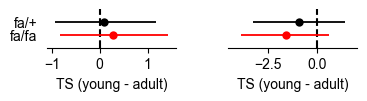

In [22]:
f, axes = plt.subplots(1, 2, figsize=(4, 0.5))
plt.subplots_adjust(wspace=0.4)

for ax, ts_, tle in zip(axes, (ts_vehicle, ts_change), ('Vehicle', 'Empagliflozin')):
    ax = forestplot_oz(ax, ts_);
    # ax.set_title(tle);
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('TS (young - adult)')
    
axes[0].set_xlim(-1.1,1.6)
axes[1].set_xlim(-4.5, 2)

# axes[1].set_xticks([-0.005, 0, 0.005], [-0.005, 0, 0.005])
# axes[0].set_xticks([-0.01, 0, 0.01], [-0.01, 0, 0.01])

axes[1].set_yticks([],[])
# plt.tight_layout()
# f.savefig(PLOT_DIR / "ts_ExcretionGlucose_CompareAgeForGtypsSexes.pdf", bbox_inches="tight")

## Compute and plot TS representing the difference between males and females

In [23]:
ts_change, ts_vehicle = (
    {
        "fa/fa":  t_groups["fa/fa:male:adult"] - t_groups["fa/fa:female:adult"],
        # "young fa/fa":   t_groups["fa/fa:male:young"] - t_groups["fa/fa:female:young"],
        "fa/+":   t_groups["fa/+:male:adult"] - t_groups["fa/+:female:adult"],
        # "young fa/+":   t_groups["fa/+:male:young"] - t_groups["fa/+:female:young"],
        # "adult": (t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"] + t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"])/2,
        # "young": (t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"] + t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"])/2,
        # "overall": (t_groups["fa/fa:young"]+t_groups["fa/fa:old"])/2 - (t_groups["fa/+:young"]+t_groups["fa/+:old"])/2,
        
    }
    for t_groups in (t_groups_change, t_groups_bsl)
)

sign_probabilities_sex = pd.DataFrame({
    'change':get_sign_probs(ts_change),
    'change_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_change).items()},
    'vehicle':get_sign_probs(ts_vehicle),
    'vehicle_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_vehicle).items()},
})

print("Empa sign probabilities:")
display(get_sign_probs(ts_change))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))

Empa sign probabilities:


{'fa/fa': 0.9055, 'fa/+': 0.58775}


Vehicle sign probabilities:


{'fa/fa': 0.454, 'fa/+': 0.6425}

[]

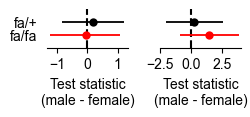

In [24]:
f, axes = plt.subplots(1, 2, figsize=(2.5, 0.5))
plt.subplots_adjust(wspace=0.4)

for ax, ts_, tle in zip(axes, (ts_vehicle, ts_change), ('Vehicle', 'Empagliflozin')):
    ax = forestplot_oz(ax, ts_);
    # ax.set_title(tle);
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('Test statistic\n(male - female)')
    
# axes[0].set_xlim(-0.006,0.007)
axes[1].set_xlim(-2.5,4)
# axes[0].set_xticks([-0.005, 0, 0.005], [-0.005, 0, 0.005])
# axes[1].set_xticks([-0.01, 0], [-0.01, 0])
axes[1].set_yticks([],[])

# f.savefig(PLOT_DIR / "ts_ExcretionGlucose_CompareSexesForGtypAges.pdf", bbox_inches="tight")

## Show sign probabilities in tables

In [25]:
sp_all = pd.concat(objs=(sign_probabilities_change,
                sign_probabilities_gtyp,
                sign_probabilities_age, 
                sign_probabilities_sex), 
                   keys=('excrGlc',
                         'fa/fa - fa/+',
                         'young - adult', 
                         'male - female'), 
                   names=('contrast', 
                          'group'))
# sp_all.to_csv('../sp_tables/ExcretionGlucose.csv')sss
sp_all

change change_signif  vehicle vehicle_signif
contrast      group                                                       
excrGlc       fa/fa adult M  0.99800             *      NaN            NaN
              fa/fa young M  0.90375                    NaN            NaN
              fa/+ adult M   0.99750             *      NaN            NaN
              fa/+ young M   0.97150                    NaN            NaN
              fa/fa adult F  0.95675                    NaN            NaN
              fa/fa young F  0.46800                    NaN            NaN
              fa/+ adult F   0.99800             *      NaN            NaN
              fa/+ young F   0.92050                    NaN            NaN
fa/fa - fa/+  M adult        0.54875                0.99650              *
              M young        0.35925                0.99750              *
              F adult        0.18875                0.99925              *
              F young        0.12450                0.99875              *
young - adult fa/fa          0.07750                0.69350               
              fa/+           0.20900                0.57400               
male - female fa/fa          0.90550                0.45400               
              fa/+           0.58775                0.64250